In [1]:
import sys
import os

sys.path.append(os.path.dirname(os.getcwd())) 

In [9]:
import pandas as pd

from pathlib import Path

from models.bert.model import BertModel

project_root = Path().resolve().parents[1]

model_path = project_root / "models" / "bert.pt"
model = BertModel.load(model_path)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3098.03it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
dataset_path = project_root / "src" / "data" / "subm1_labels_revealed.csv"

df = pd.read_csv(dataset_path, sep=";")

In [11]:
X = df["Text"].tolist()
y = df["Label"].tolist()

predicted_labels = model.predict(X, y)

Accuracy: 73/100 (73.00%)


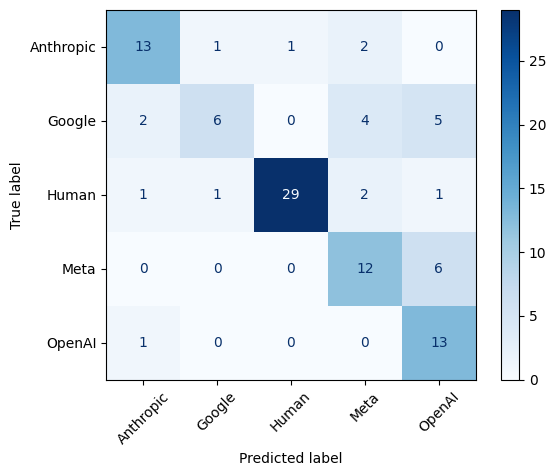

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.label_map.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

## BERT Architecture and Pipeline Visualization

The following plots provide a paper-style architecture view and a training workflow view for the BERT/RoBERTa classifier used in this project.

/Users/diego/Workspace/Simb/mia/2-semestre/trabalhos/AP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


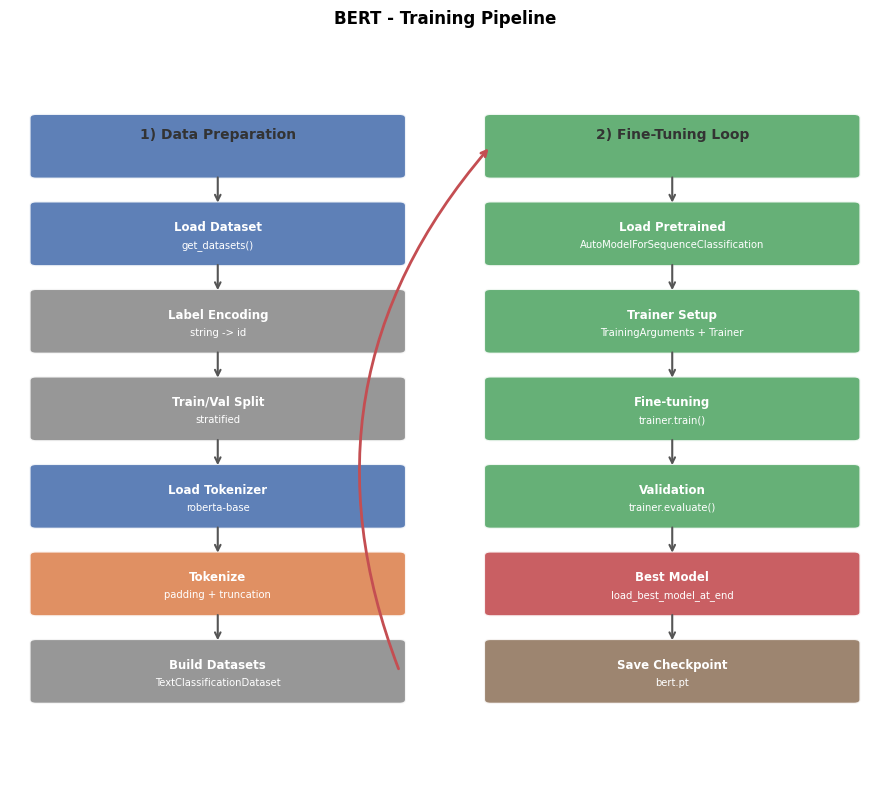

In [2]:
from models.bert.train import BertTrainer

BertTrainer.plot_pipeline()

/Users/diego/Workspace/Simb/mia/2-semestre/trabalhos/AP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


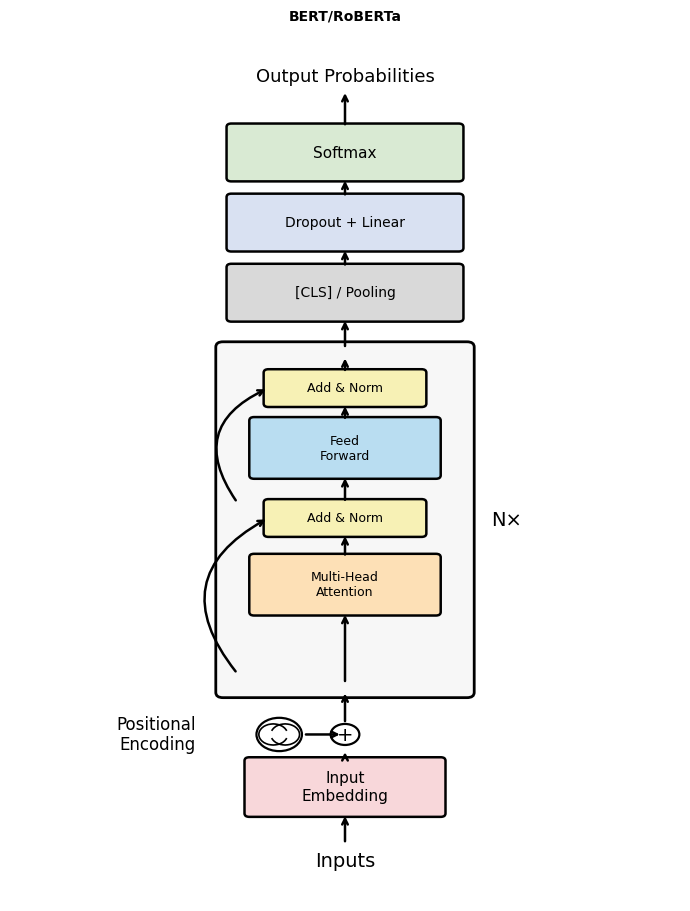

In [1]:
import sys
import os

sys.path.append(os.path.dirname(os.getcwd())) 

from models.bert.train import BertTrainer

# Paper-style Transformer architecture diagram (encoder-decoder layout)
BertTrainer.plot_paper_transformer_architecture()